In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

# data cleaning

In [2]:
path = r"C:\Users\JoudA\ML NUI COURSE\IKEA_product_catalog.csv"
ikea = pd.read_csv(path)
ikea.head()

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country
0,10018194-Australia,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,3.3,140.0,none,True,https://www.ikea.com/au/en/p/ordning-dish-drai...,30.00,AUD,none,NONE,Australia
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.3,6.0,none,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.99,EUR,none,NONE,Austria
2,10018194-Bahrain,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,1.0,1.0,none,True,https://www.ikea.com/bh/en/p/ordning-dish-drai...,9.50,BHD,none,NONE,Bahrain
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.99,EUR,none,NONE,Belgium
4,10018194-Canada,10018194,ORDNING,Dish drainer,"50x27x36 cm (19 5/8x10 5/8x14 1/8 "")","ORDNING Dish drainer, stainless steel, 19 5/8x...",kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/ca/en/p/ordning-dish-drai...,34.99,CAD,none,NONE,Canada


In [3]:
ikea.info()
print("\nDiscribe")
ikea.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401046 entries, 0 to 401045
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   unique_id             401046 non-null  object 
 1   product_id            401046 non-null  int64  
 2   product_name          401046 non-null  object 
 3   product_type          401046 non-null  object 
 4   product_measurements  401046 non-null  object 
 5   product_description   401046 non-null  object 
 6   main_category         401046 non-null  object 
 7   sub_category          401046 non-null  object 
 8   product_rating        401046 non-null  object 
 9   product_rating_count  401046 non-null  object 
 10  badge                 401046 non-null  object 
 11  online_sellable       401046 non-null  bool   
 12  url                   401046 non-null  object 
 13  price                 401046 non-null  float64
 14  currency              401046 non-null  object 
 15  

,unique_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,url,currency,discount,sale_tag,country
count,401046,401046,401046,401046,401046,401046,401046,401046,401046,401046,401046,401046,401046,401046,401046
unique,401046,4289,32849,10675,163776,314,2299,41,1453,3,401046,34,25,6,46
top,10018194-Australia,TROFAST,Wardrobe combination,none,"SKÅDIS Pegboard combination, white, 36x56 cm",storage-organisation,storage-solution-systems,none,none,none,https://www.ikea.com/au/en/p/ordning-dish-drai...,EUR,none,NONE,Sweden
freq,1,5911,8407,99902,144,52037,32801,131960,131960,372043,1,124436,400918,330134,10722


In [4]:
# Standardizing missing values: Replace various 'none' strings with a calculatable NaN 
ikea.replace(['none', 'None', 'NONE'], np.nan, inplace=True)

# Calculating the percentage of missing values (Nulls) for each feature
null_counts = ikea.isnull().sum()
null_percentages = (ikea.isnull().sum() / len(ikea)) * 100
for column, percentage in null_percentages.items():
    print(f"{column}: {percentage:.2f}%")

unique_id: 0.00%
product_id: 0.00%
product_name: 0.00%
product_type: 0.04%
product_measurements: 24.91%
product_description: 0.01%
main_category: 0.00%
sub_category: 0.00%
product_rating: 32.90%
product_rating_count: 32.90%
badge: 92.77%
online_sellable: 0.00%
url: 0.00%
price: 0.00%
currency: 0.00%
discount: 99.97%
sale_tag: 82.32%
country: 0.00%


In [5]:
# remove columns with more than 80% missing values
ikea.drop(columns=['discount', 'badge', 'sale_tag'], inplace=True)

# remove rows with rating missing values
ikea.dropna(subset=['product_rating', 'product_rating_count'], inplace=True)

# Ensure numerical columns are in the correct format 
ikea['price'] = pd.to_numeric(ikea['price'], errors='coerce')
ikea['product_rating'] = pd.to_numeric(ikea['product_rating'], errors='coerce')

ikea.describe(include='object')

,unique_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating_count,url,currency,country
count,269086,269086,269028,199185,269085,269086,269086,269086,269086,269086,269086
unique,269086,4053,28797,9650,128595,311,2248,1452,269086,31,43
top,10018194-Australia,IKEA 365+,Cushion cover,50x50 cm,"SKÅDIS Pegboard combination, white, 36x56 cm",storage-organisation,storage-solution-systems,1.0,https://www.ikea.com/au/en/p/ordning-dish-drai...,EUR,Sweden
freq,1,3878,1887,2245,79,26591,14993,32080,1,93489,9395


In [6]:
print(ikea['currency'].unique())

['AUD' 'EUR' 'BHD' 'CAD' 'CLP' 'COP' 'CZK' 'DKK' 'EGP' 'HUF' 'INR' 'JPY'
 'MYR' 'MXN' 'NZD' 'NOK' 'OMR' 'PHP' 'PLN' 'QAR' 'RON' 'SAR' 'RSD' 'SGD'
 'KRW' 'SEK' 'CHF' 'THB' 'AED' 'GBP' 'USD']


In [7]:
# all to SAR
exchange_to_sar = {
    'SAR': 1.000, 'USD': 3.750, 'AED': 1.021, 'KWD': 12.185, 'BHD': 9.947,
    'OMR': 9.741, 'QAR': 1.030, 'JOD': 5.289, 'GBP': 4.724, 'EUR': 4.053,
    'CHF': 4.142, 'CAD': 2.756, 'AUD': 2.449, 'SGD': 2.783, 'NZD': 2.251,
    'JPY': 0.024, 'SEK': 0.352, 'NOK': 0.348, 'DKK': 0.543, 'PLN': 0.942,
    'INR': 0.045, 'MYR': 0.792, 'MXN': 0.221, 'PHP': 0.067, 'THB': 0.103,
    'KRW': 0.0028, 'CZK': 0.161, 'HUF': 0.010, 'RON': 0.815, 'CLP': 0.004,
    'COP': 0.0009, 'EGP': 0.078, 'MAD': 0.372, 'RSD': 0.034
}
ikea['price'] = ikea['price'] * ikea['currency'].map(exchange_to_sar)
ikea.drop(columns=['currency'], inplace=True)
ikea.describe()

,product_id,product_rating,price
count,2.690860e+05,269086.000000,269086.000000
mean,4.725659e+07,4.455271,425.144544
std,2.950668e+07,0.617955,844.262274
min,2.850800e+04,1.000000,0.689000
25%,2.052361e+07,4.300000,30.797000
50%,4.960405e+07,4.600000,101.325000
75%,7.057508e+07,4.800000,425.160000
max,9.993162e+07,5.000000,17425.850000


In [8]:
# Check for total duplicates 
total_duplicates = ikea.duplicated().sum()
print("Total exact duplicate rows",total_duplicates)

# Check for duplicate IDs 
id_duplicates = ikea.duplicated(subset=['unique_id']).sum()
print("Duplicate unique_ids", id_duplicates)

Total exact duplicate rows 0
Duplicate unique_ids 0


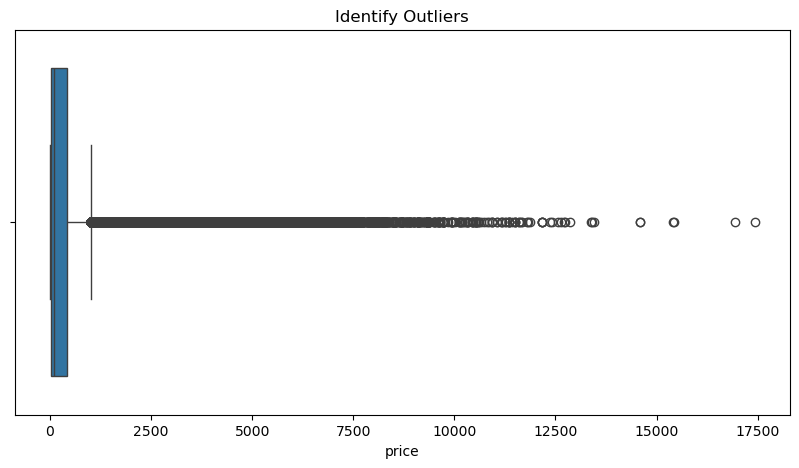

count    269086.000000
mean        425.144544
std         844.262274
min           0.689000
25%          30.797000
50%         101.325000
75%         425.160000
max       17425.850000
Name: price, dtype: float64

In [9]:
# Chech for Identify outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=ikea['price'])
plt.title('Identify Outliers')
plt.show()

ikea.price.describe()

# Data Cleaning & Preprocessing Report
## Rationale for Cleaning

Ensure reliable analysis and AI modeling.
Handle multiple currencies (31) for consistent price comparison.
Remove rows with missing ratings to focus on verified market feedback.
Drop features with too many nulls (>80%) to reduce noise.

## Cleaning Steps
Step 1: Feature Selection

Dropped sparse columns: discount (99.9%), badge (92.7%), sale_tag (82.3%).

Step 2: Handling Missing Values

Removed rows with null product_rating or product_rating_count (~32.9%).

Dataset reduced from 401,046 → 269,086 complete rows.

Step 3: Currency Normalization

Converted all prices to Saudi Riyal (SAR) using 2026 rates.

Dropped the redundant currency column.

Step 4: Duplicates & Outliers

No duplicate rows found.

Price outliers retained as they reflect realistic product differences (e.g., a screw vs. a full kitchen set).

# visualization

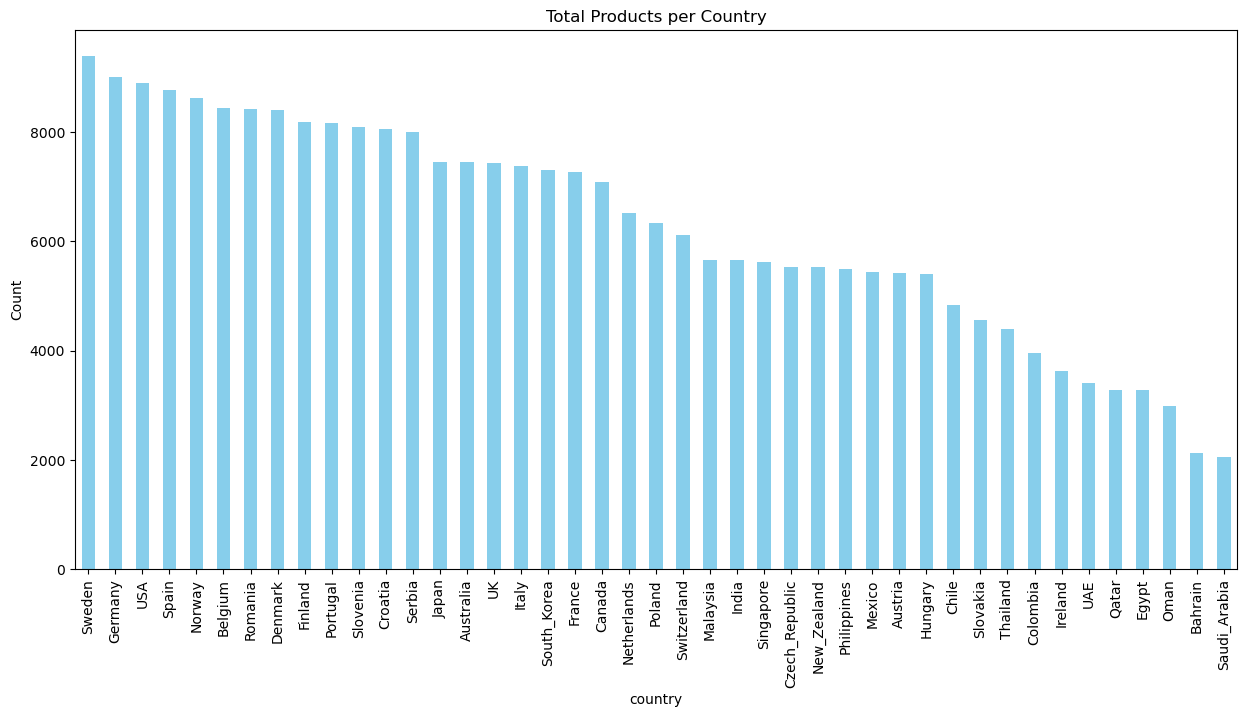

In [10]:
plt.figure(figsize=(15, 7))
ikea['country'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Total Products per Country')
plt.ylabel('Count')
plt.show()

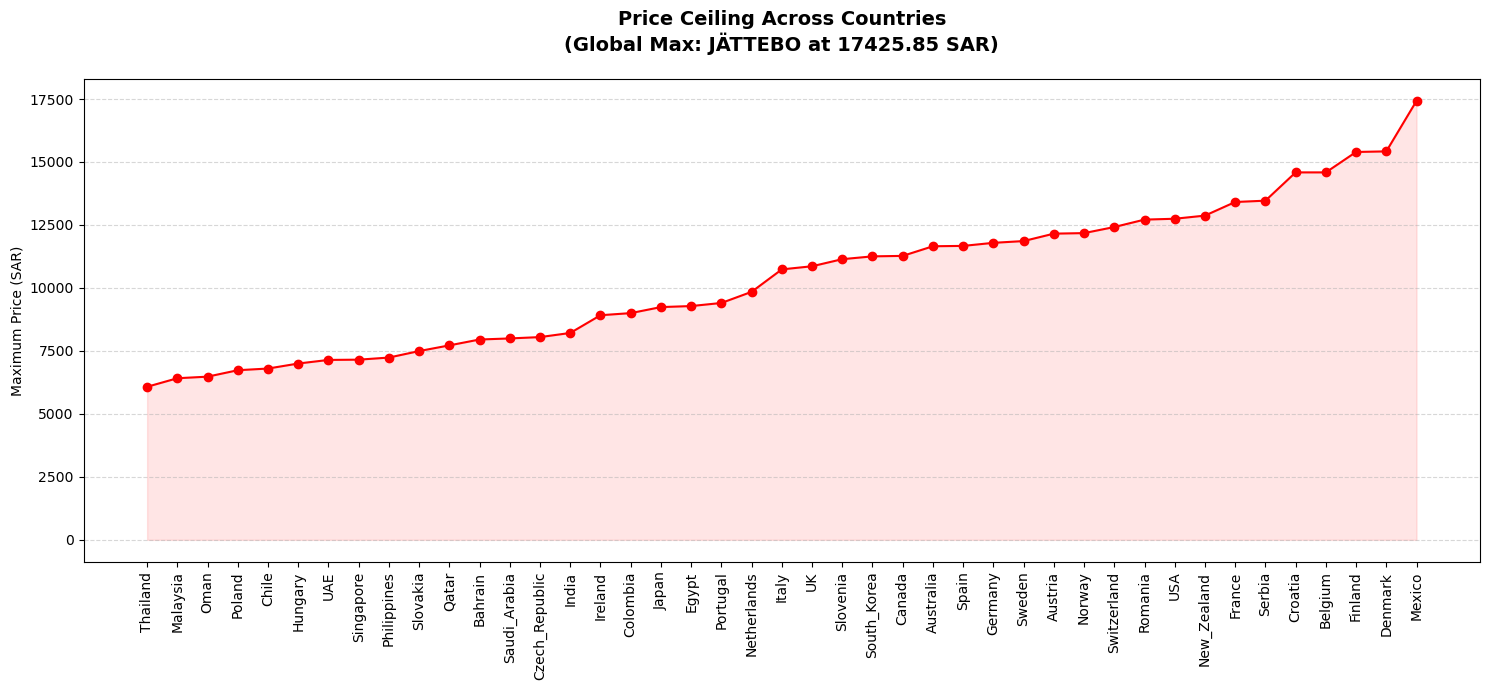

In [11]:
max_indices = ikea.groupby('country')['price'].idxmax()
max_price_line = ikea.loc[max_indices, ['country', 'product_name', 'price']].sort_values(by='price').reset_index()

world_expensive_item = max_price_line.iloc[-1] 
title_text = f"Price Ceiling Across Countries\n(Global Max: {world_expensive_item['product_name']} at {world_expensive_item['price']} SAR)"

plt.figure(figsize=(15, 7))
plt.plot(max_price_line['country'], max_price_line['price'], marker='o', color='red')
plt.fill_between(max_price_line['country'], max_price_line['price'], color="red", alpha=0.1)

plt.xticks(rotation=90)
plt.title(title_text, fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Maximum Price (SAR)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

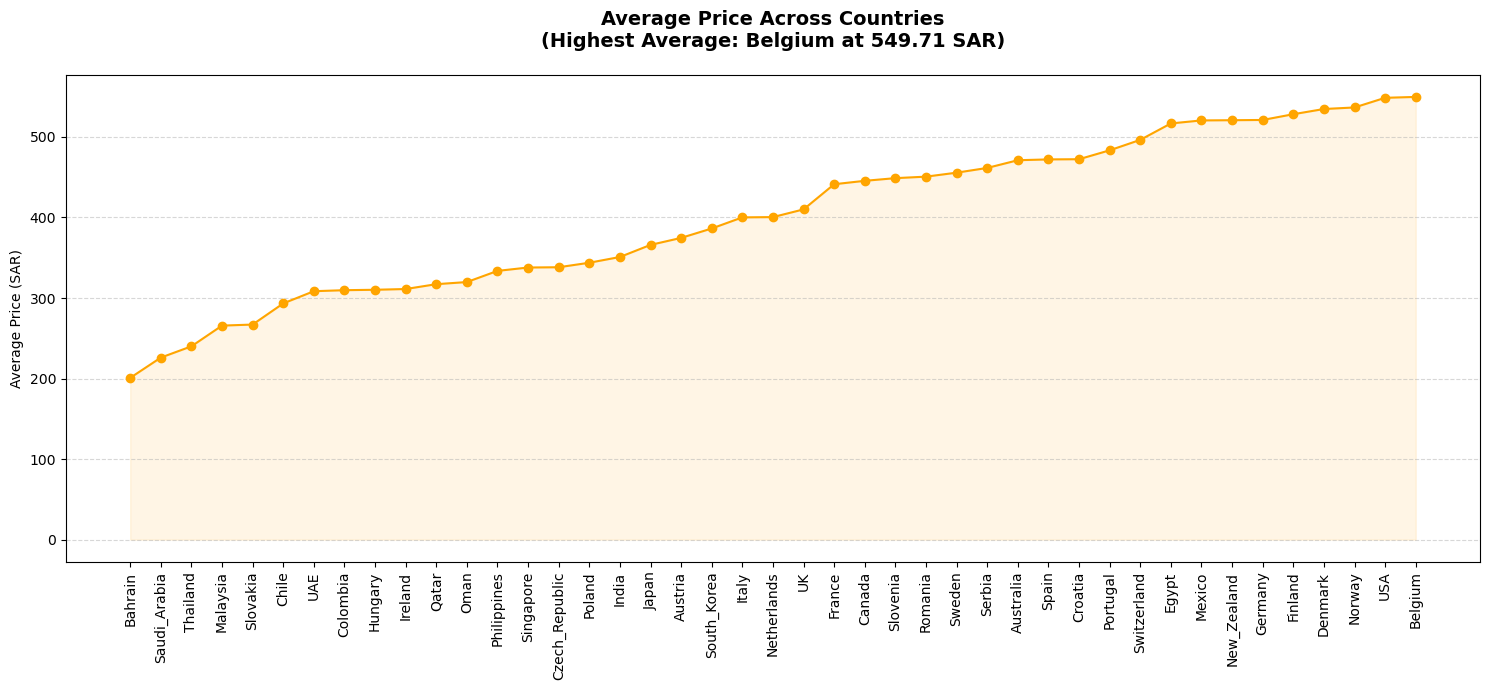

In [12]:
mean_price_data = ikea.groupby('country')['price'].mean().sort_values().reset_index()

highest_mean_country = mean_price_data.iloc[-1] 
title_text = f"Average Price Across Countries\n(Highest Average: {highest_mean_country['country']} at {highest_mean_country['price']:.2f} SAR)"

plt.figure(figsize=(15, 7))
plt.plot(mean_price_data['country'], mean_price_data['price'], marker='o', color='orange')
plt.fill_between(mean_price_data['country'], mean_price_data['price'], color="orange", alpha=0.1)

plt.xticks(rotation=90)
plt.title(title_text, fontsize=14, fontweight='bold', pad=20) 
plt.ylabel('Average Price (SAR)') 
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

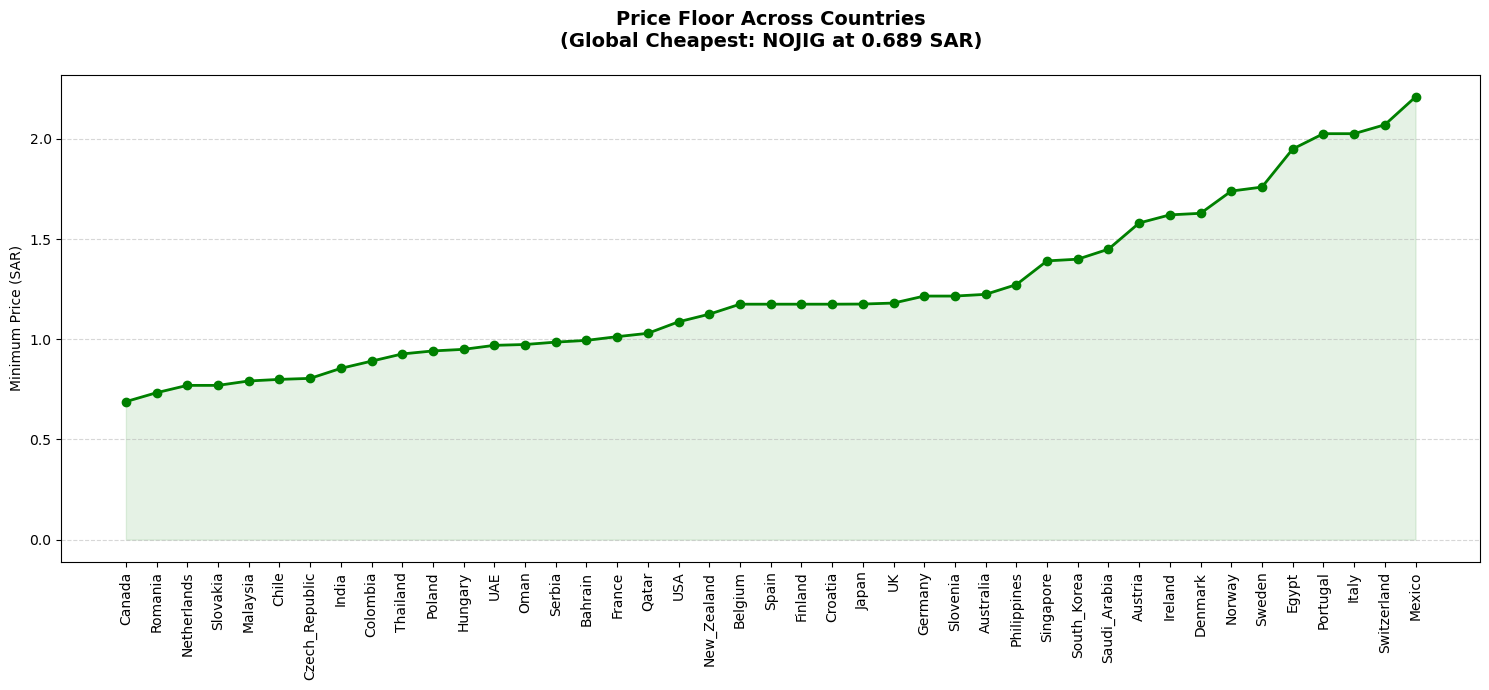

In [13]:
min_indices = ikea.groupby('country')['price'].idxmin()
min_price_line = ikea.loc[min_indices, ['country', 'product_name', 'price']].sort_values(by='price').reset_index()

world_cheapest_item = min_price_line.iloc[0] 
title_text = f"Price Floor Across Countries\n(Global Cheapest: {world_cheapest_item['product_name']} at {world_cheapest_item['price']} SAR)"

plt.figure(figsize=(15, 7))
plt.plot(min_price_line['country'], min_price_line['price'], marker='o', color='green', linewidth=2)
plt.fill_between(min_price_line['country'], min_price_line['price'], color="green", alpha=0.1)

plt.xticks(rotation=90)
plt.title(title_text, fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Minimum Price (SAR)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

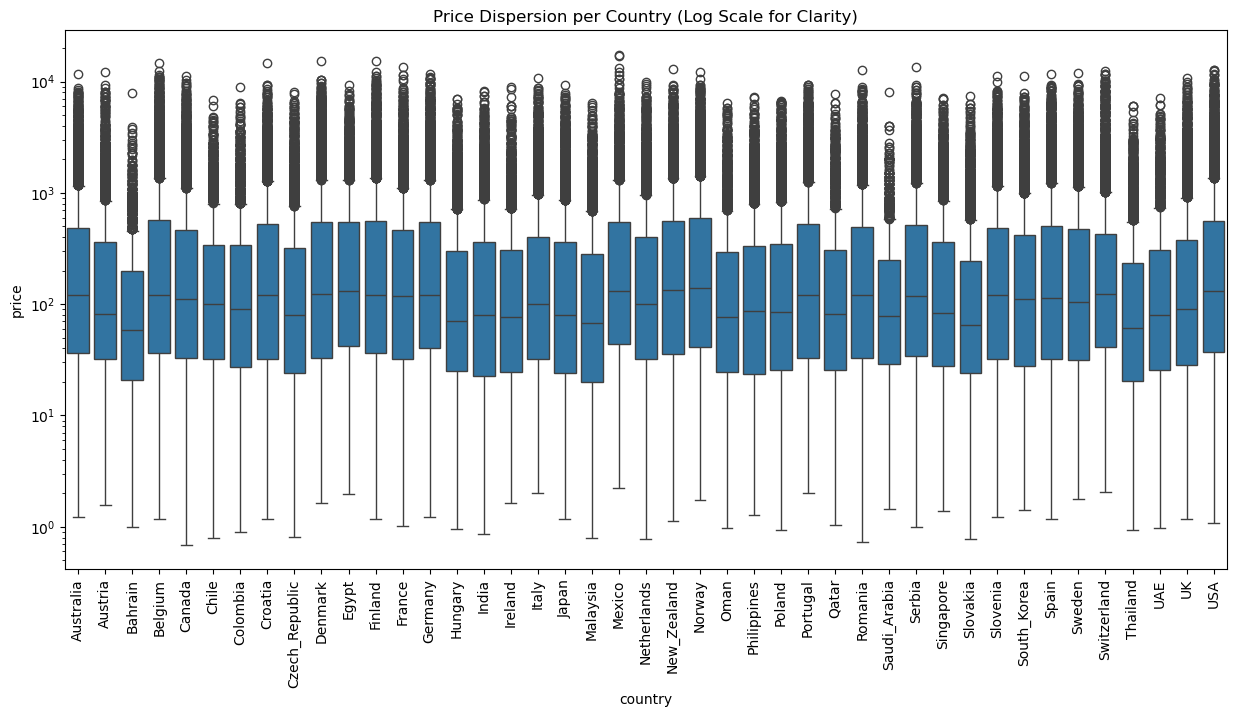

In [14]:
"""
Logarithmic scale was applied to the price axis to
normalize the high skewness between low-cost items (5SAR) 
and luxury furniture (15,000 SAR), ensuring all
country distributions are visible and comparable.
"""
plt.figure(figsize=(15, 7))
sns.boxplot(data=ikea, x='country', y='price')
plt.yscale('log') 
plt.xticks(rotation=90, fontsize=10)
plt.title('Price Dispersion per Country (Log Scale for Clarity)')

plt.show()

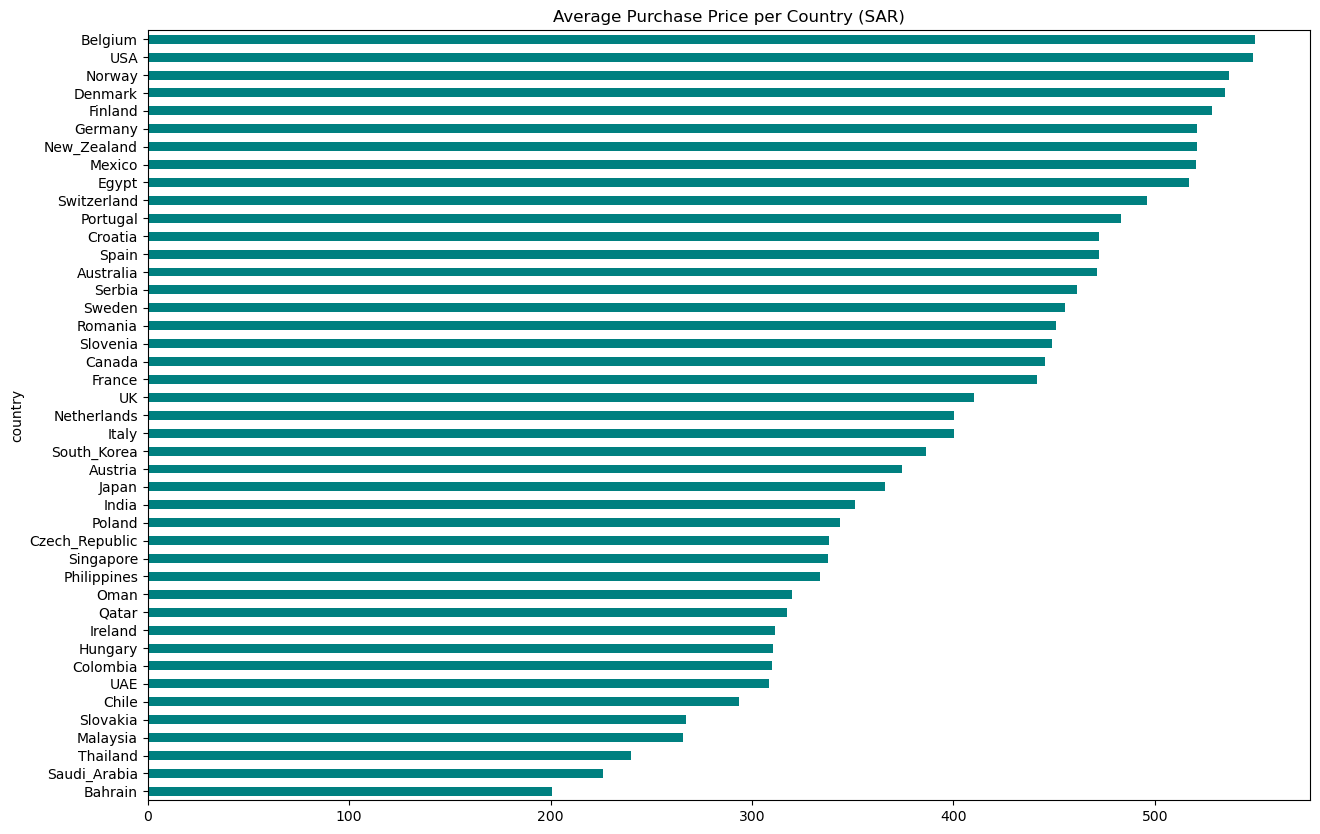

In [15]:
plt.figure(figsize=(15,10))
ikea.groupby('country')['price'].mean().sort_values().plot(kind='barh', color='teal')
plt.title('Average Purchase Price per Country (SAR)')
plt.show()

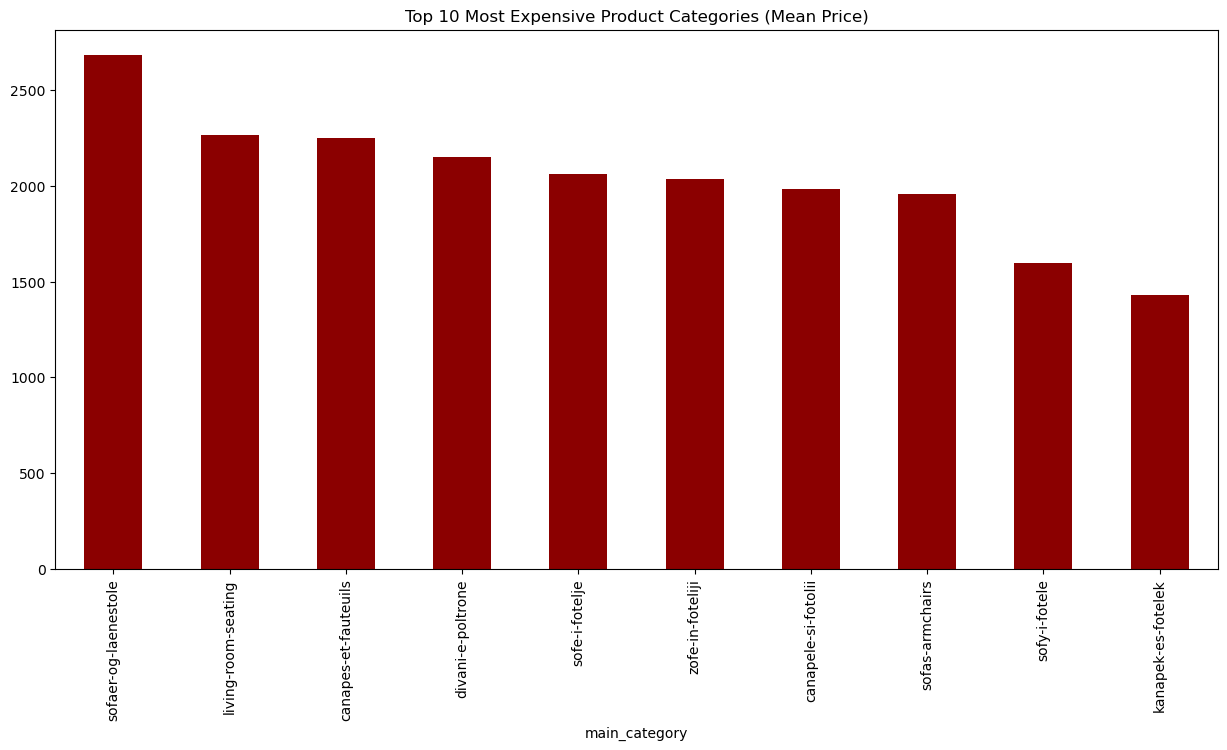

In [16]:
top_10_cats = ikea.groupby('main_category')['price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(15, 7))
top_10_cats.plot(kind='bar', color='darkred')
plt.title('Top 10 Most Expensive Product Categories (Mean Price)')
plt.show()

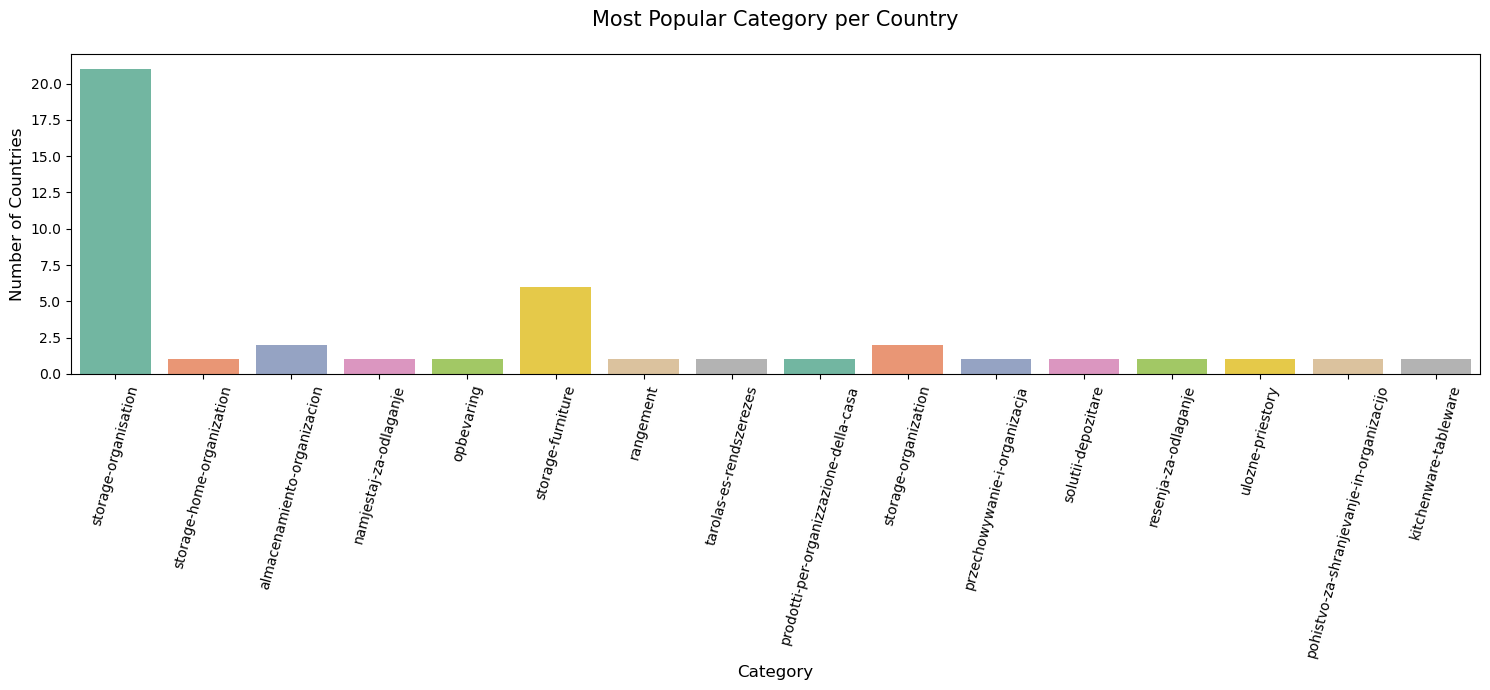

In [17]:
top_categories = ikea.groupby('country')['main_category'].apply(lambda x: x.value_counts().idxmax()).reset_index()
top_categories.columns = ['country', 'top_category']

plt.figure(figsize=(15,7))
sns.countplot(data=top_categories, x='top_category', palette='Set2', hue='top_category', legend=False)

plt.title('Most Popular Category per Country', fontsize=15, pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

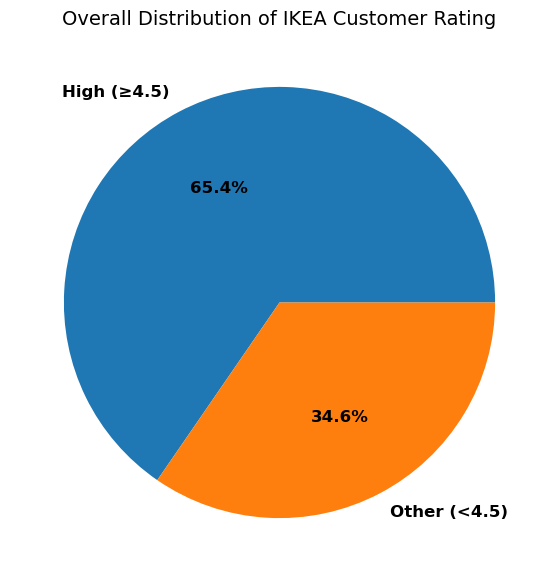

In [32]:
high_rating_count = ikea['rating'][ikea['rating'] >= 4.5].count()
other_rating_count = ikea['rating'].count() - high_rating_count

ratings_counts = [high_rating_count, other_rating_count]
ratings_labels = ['High (≥4.5)', 'Other (<4.5)']

plt.figure(figsize=(15, 7))
plt.pie(ratings_counts, labels=ratings_labels, autopct='%1.1f%%',textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Overall Distribution of IKEA Customer Rating', fontsize=14)

plt.show()

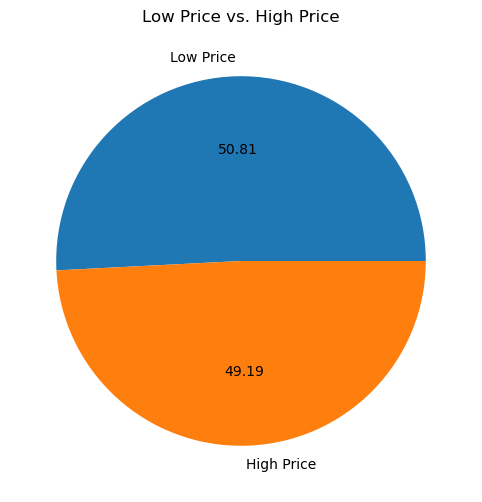

In [43]:
median_price = ikea['price'].median()
low_price_avg = ikea[ikea['price'] <= median_price]['rating'].mean()
high_price_avg = ikea[ikea['price'] > median_price]['rating'].mean()

labels = ['Low Price', 'High Price']
sizes = [low_price_avg, high_price_avg]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels,autopct='%1.2f')
plt.title('Low Price vs. High Price')
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
C:\Users\JoudA\AppData\Local\Temp\ipykernel_37556\1995453117.py:3: SyntaxWarning: invalid escape sequence '\d'
  x=pd.to_numeric(ikea['product_measurements'].astype(str).str.extract('(\d+)')[0], errors='coerce'),
C:\Users\JoudA\AppData\Local\Temp\ipykernel_37556\1995453117.py:16: SyntaxWarning: invalid escape sequence '\d'
  size_numeric = pd.to_numeric(ikea['product_measurements'].astype(str).str.extract('(\d+)')[0], errors='coerce')


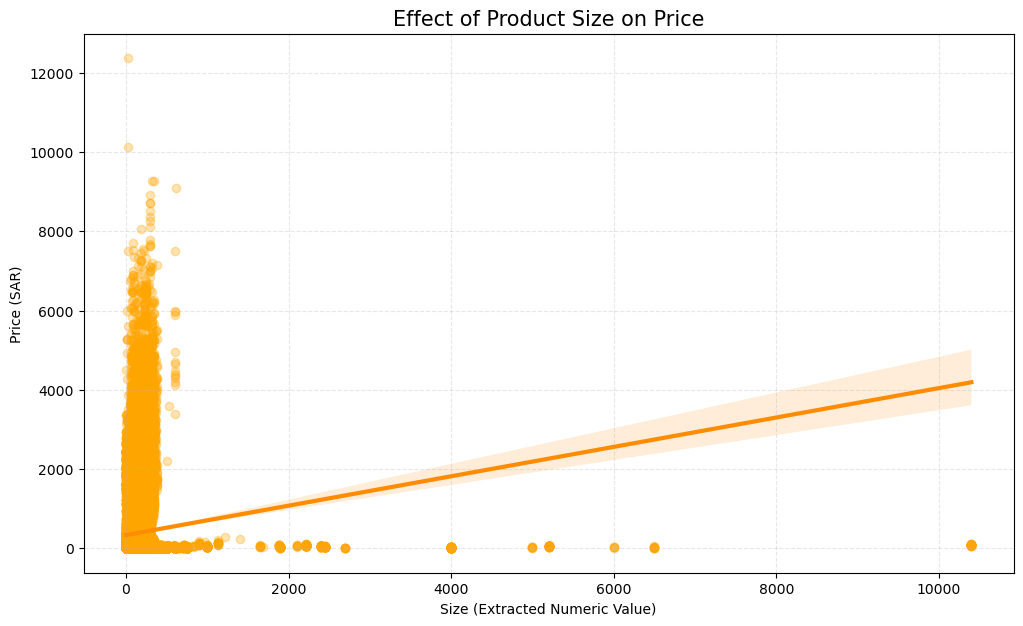

Correlation between Size and Price: 0.11747574051368952
Avg Price (Top 10% Largest Items):  925.9372548331046
Avg Price (Bottom 10% Smallest Items): 71.28658720563266
Price Gap Percentage: 1198.8940712818164


In [25]:
plt.figure(figsize=(12, 7))
sns.regplot(
    x=pd.to_numeric(ikea['product_measurements'].astype(str).str.extract('(\d+)')[0], errors='coerce'), 
    y=ikea['price'],
    scatter_kws={'alpha':0.3, 'color':'orange'},
    line_kws={'color':'darkorange', 'linewidth':3}
)

plt.title('Effect of Product Size on Price', fontsize=15)
plt.xlabel('Size (Extracted Numeric Value)')
plt.ylabel('Price (SAR)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

size_numeric = pd.to_numeric(ikea['product_measurements'].astype(str).str.extract('(\d+)')[0], errors='coerce')
price_numeric = pd.to_numeric(ikea['price'], errors='coerce')

correlation = size_numeric.corr(price_numeric)
temp_df = pd.DataFrame({'size': size_numeric, 'price': price_numeric}).dropna()
top_10_price = temp_df.nlargest(int(len(temp_df)*0.1), 'size')['price'].mean()
bottom_10_price = temp_df.nsmallest(int(len(temp_df)*0.1), 'size')['price'].mean()

price_increase_pct = ((top_10_price - bottom_10_price) / bottom_10_price) * 100

# Output results
print("Correlation between Size and Price:" , correlation)
print("Avg Price (Top 10% Largest Items): ", top_10_price)
print("Avg Price (Bottom 10% Smallest Items):", bottom_10_price)
print("Price Gap Percentage:", price_increase_pct)

# CONCLUSIONS FOR EACH VISUALIZATION
### 1. Outliers Analysis
Although there are extremely high prices (up to 17,425 SAR), most products fall within a lower range (around 100–400 SAR).
Insight: The market is dominated by low-cost products, with a very small segment of luxury items.

### 2. Products per Country
Sweden has the highest number of products, while Saudi Arabia represents the smallest market.
Insight: Sweden is the core IKEA market, whereas some markets (such as Saudi Arabia) offer less product diversity.

### 3. Price Ceiling
The most expensive product is found in Mexico at a very high price.
Insight: Some markets support premium luxury products, indicating the presence of high purchasing power segments.

### 4. Average Price
Belgium has the highest average prices, while the global average is significantly lower.
Insight: Purchasing power varies across countries, with some markets leaning toward higher-priced products.

### 5. Price Floor
The cheapest product is priced at a very minimal value (0.69 SAR).
Insight: IKEA offers extremely affordable products, making it accessible to all customer segments.

### 6. Price Dispersion
The high standard deviation indicates a wide variation in prices.
Insight: The market includes a broad range of products, from low-cost to premium items.

### 7. Purchase Power
Average spending differs significantly between countries.
Insight: Each market has its own purchasing power, which influences pricing strategies and product positioning.

### 8. Luxury Categories
Sofas and armchairs are the most expensive category.
Insight: Large and essential home furniture represents the premium segment in IKEA.

### 9. Dominant Categories
Storage and organization is the most popular category globally.
Insight: This reflects a universal need for organization solutions across all markets.

### 10. Ratings Split
Most ratings are high (65%+).
Insight: Customers are generally satisfied with IKEA products.

### 11. Sentiment & Price
Lower-priced products tend to receive higher ratings than expensive ones.
Insight: A higher price does not guarantee customer satisfaction, and expectations may be higher for expensive products.

### 12. Size Impact
The relationship between size and price is weak, although larger products are significantly more expensive.
Insight: Price is not solely driven by size, but also by other factors such as design and quality.

## Final Insight

The market is global and highly diverse

Price does not determine customer satisfaction

Global demand is highest for practical products (storage solutions)

IKEA serves all segments, from low-cost to premium